# 04 - Hyperparameter Optimization

# Optimización de hiperparámetros y análisis comparativo de modelos

En esta etapa del proyecto se realizó una optimización de hiperparámetros sobre distintos modelos de clasificación con el objetivo de mejorar la predicción de la variable:

`entrega_tardia_v2`

Esta variable fue creada previamente para representar si una entrega tardó más de 7 días:

- `0` → entrega normal
- `1` → entrega tardía

En los notebooks anteriores se detectó que la variable original `entrega_tardia` presentaba un desbalance extremo, lo que provocaba que los modelos obtuvieran un accuracy muy alto sin realmente detectar entregas tardías.

Por esta razón se construyó `entrega_tardia_v2`, generando una distribución más adecuada para clasificación supervisada.

El propósito principal de este notebook es analizar si la optimización de hiperparámetros permite mejorar el rendimiento de los modelos, especialmente en la detección de entregas tardías.


# Objetivos del notebook

En este notebook se busca:

- Optimizar modelos utilizando `GridSearchCV`.
- Aplicar `Optuna` como técnica avanzada de optimización automática.
- Comparar modelos base y modelos optimizados.
- Analizar el comportamiento de las métricas en un problema desbalanceado.
- Determinar cuál modelo logra el mejor equilibrio entre detección y precisión.
- Justificar técnicamente la selección del modelo final.

A diferencia de las etapas anteriores, aquí el foco principal está en el análisis experimental y la interpretación de resultados.


# 1. Configuración inicial

In [1]:
%load_ext kedro.ipython

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset final

Se utiliza el dataset final generado desde Kedro (`dataset_modelo`), el cual ya contiene la integración y transformación de los datos logísticos trabajados en la evaluación anterior.


In [2]:
df = catalog.load("dataset_modelo")

df.head()


[05/09/26 20:36:03] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=5903578;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=5903579;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Construcción de la variable objetivo

La variable objetivo utilizada será:

`entrega_tardia_v2`

Esta variable se define como:

- `1` → entrega demoró más de 7 días.
- `0` → entrega demoró 7 días o menos.

Esta decisión se tomó debido a que la variable original generaba un desbalance demasiado extremo para trabajar correctamente con modelos supervisados.


In [3]:
df["entrega_tardia_v2"] = (df["dias_entrega"] > 7).astype(int)

df["entrega_tardia_v2"].value_counts()



entrega_tardia_v2
0    929
1    101
Name: count, dtype: int64

In [4]:
df["entrega_tardia_v2"].value_counts(normalize=True) * 100



entrega_tardia_v2
0    90.194175
1     9.805825
Name: proportion, dtype: float64

## Análisis

La nueva distribución sigue siendo desbalanceada, pero ahora existe una cantidad suficiente de casos positivos para trabajar con clasificación.

Esto es importante porque anteriormente casi todos los registros pertenecían a una sola clase, provocando que algunos modelos simplemente predijeran siempre la clase mayoritaria.

Con esta nueva definición, los modelos tienen más posibilidades de aprender patrones asociados a entregas tardías reales.


# 4. Selección de variables predictoras

Se utilizan variables relacionadas con:

- distancia,
- tiempo estimado,
- capacidad,
- incidencias,
- velocidad,
- tipo de carga,
- tipo de vía.

No se utiliza `dias_entrega` porque esa variable fue usada directamente para construir el target.


In [5]:
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

objetivo = "entrega_tardia_v2"

X = df[variables_modelo]
y = df[objetivo]

print(X.shape)
print(y.shape)


(1030, 14)
(1030,)


# 5. Preprocesamiento

Se construye un pipeline de preprocesamiento utilizando `Scikit-learn`.

## Variables numéricas
- imputación con mediana,
- escalado estándar.

## Variables categóricas
- imputación con valor más frecuente,
- codificación OneHotEncoder.

Este enfoque permite trabajar correctamente con valores nulos y variables categóricas sin modificar manualmente el dataset original.


In [6]:
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 6. División entrenamiento y prueba

Se utiliza una división:

- 80% entrenamiento
- 20% prueba

Además, se aplica `stratify=y` para conservar la proporción de clases en ambos conjuntos.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (824, 14)
X_test: (206, 14)


# 7. Función de evaluación

La siguiente función permite evaluar cualquier modelo utilizando métricas relevantes para problemas desbalanceados.

Se utilizarán principalmente:

- Recall
- F1-score
- Balanced Accuracy

El accuracy no será la métrica principal, ya que podría resultar engañoso en este contexto.


In [8]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()

    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


# 8. Modelo base - Decision Tree

En el notebook anterior, el modelo base con mejor F1-score fue `Decision Tree`, por lo que se utilizará como referencia inicial antes de aplicar optimización.


===== Decision Tree Base =====
Accuracy          : 0.7621
Balanced Accuracy : 0.5559
Precision         : 0.1463
Recall            : 0.3000
F1-score          : 0.1967

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       186
           1       0.15      0.30      0.20        20

    accuracy                           0.76       206
   macro avg       0.53      0.56      0.53       206
weighted avg       0.84      0.76      0.80       206



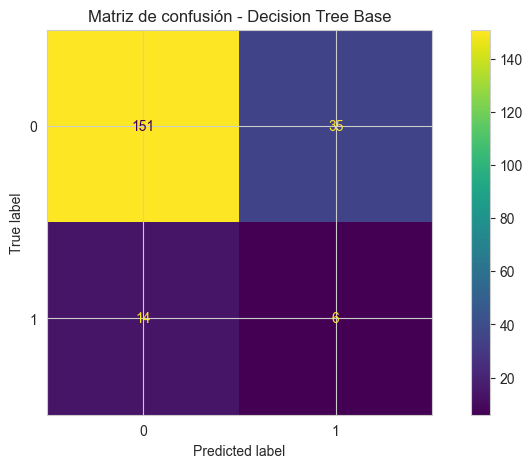

In [9]:
modelo_tree_base = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ))
])

modelo_tree_base.fit(X_train, y_train)

resultado_tree_base = evaluar_modelo(
    "Decision Tree Base",
    modelo_tree_base,
    X_test,
    y_test
)


## Análisis del modelo base

El modelo base obtiene un F1-score cercano a 0.20, logrando detectar parte de las entregas tardías.

Aunque el accuracy es relativamente alto, el valor más importante en este caso es el recall, ya que el objetivo del proyecto es identificar entregas problemáticas y no solamente acertar registros normales.

Este modelo será utilizado como punto de comparación para analizar si la optimización realmente mejora el rendimiento.


# 9. Optimización con GridSearchCV - Decision Tree

`GridSearchCV` permite probar múltiples combinaciones de hiperparámetros mediante validación cruzada.

En este caso se optimizan:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `criterion`

La métrica principal utilizada será `f1`.


In [10]:
pipeline_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_tree = {
    "modelo__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 5, 10],
    "modelo__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__criterion': ['gini', 'entropy'], 'modelo__max_depth': [2, 3, ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [11]:
print("Mejores parámetros Decision Tree:")
print(grid_tree.best_params_)

print("\nMejor F1 promedio:")
print(grid_tree.best_score_)


Mejores parámetros Decision Tree:
{'modelo__criterion': 'entropy', 'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5}

Mejor F1 promedio:
0.1852963508742936


===== Decision Tree GridSearchCV =====
Accuracy          : 0.5485
Balanced Accuracy : 0.4599
Precision         : 0.0805
Recall            : 0.3500
F1-score          : 0.1308

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.57      0.70       186
           1       0.08      0.35      0.13        20

    accuracy                           0.55       206
   macro avg       0.49      0.46      0.41       206
weighted avg       0.81      0.55      0.64       206



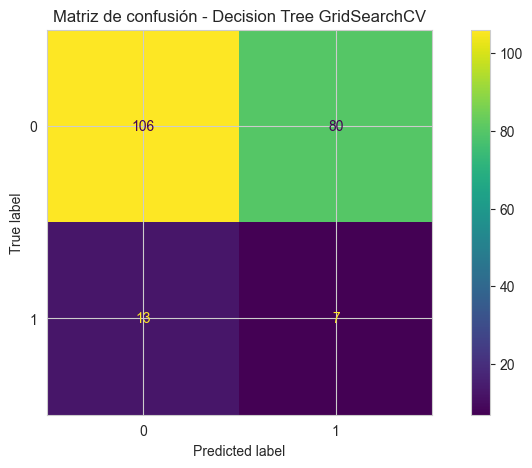

In [12]:
modelo_tree_grid = grid_tree.best_estimator_

resultado_tree_grid = evaluar_modelo(
    "Decision Tree GridSearchCV",
    modelo_tree_grid,
    X_test,
    y_test
)


## Análisis del GridSearchCV sobre Decision Tree

Aunque `GridSearchCV` encontró una combinación de hiperparámetros distinta al modelo base, el rendimiento final en el conjunto de prueba fue inferior.

El modelo optimizado logró aumentar ligeramente el recall, pero redujo considerablemente la precisión y el F1-score general.

Esto demuestra algo importante en Machine Learning:

> obtener mejores resultados en validación cruzada no garantiza necesariamente un mejor rendimiento real en datos no vistos.

En este caso, el árbol optimizado parece haberse vuelto más sensible para detectar positivos, pero a costa de generar demasiados falsos positivos.


# 10. Optimización con GridSearchCV - Logistic Regression

También se optimiza `Logistic Regression` para comparar si un modelo lineal puede comportarse mejor frente al desbalance de clases.


In [13]:
pipeline_logistic = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=2000
    ))
])

param_grid_logistic = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__solver": ["liblinear", "lbfgs"],
    "modelo__class_weight": [None, "balanced"]
}

grid_logistic = GridSearchCV(
    estimator=pipeline_logistic,
    param_grid=param_grid_logistic,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__C': [0.01, 0.1, ...], 'modelo__class_weight': [None, 'balanced'], 'modelo__solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [14]:
print("Mejores parámetros Logistic Regression:")
print(grid_logistic.best_params_)

print("\nMejor F1 promedio:")
print(grid_logistic.best_score_)


Mejores parámetros Logistic Regression:
{'modelo__C': 0.1, 'modelo__class_weight': 'balanced', 'modelo__solver': 'lbfgs'}

Mejor F1 promedio:
0.18733485739478445


===== Logistic Regression GridSearchCV =====
Accuracy          : 0.6505
Balanced Accuracy : 0.5610
Precision         : 0.1286
Recall            : 0.4500
F1-score          : 0.2000

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78       186
           1       0.13      0.45      0.20        20

    accuracy                           0.65       206
   macro avg       0.52      0.56      0.49       206
weighted avg       0.84      0.65      0.72       206



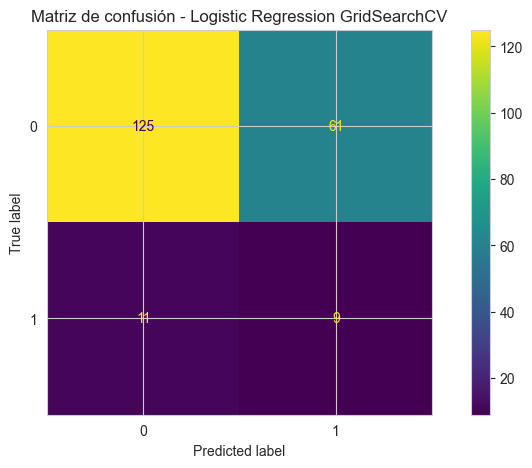

In [15]:
modelo_logistic_grid = grid_logistic.best_estimator_

resultado_logistic_grid = evaluar_modelo(
    "Logistic Regression GridSearchCV",
    modelo_logistic_grid,
    X_test,
    y_test
)


## Análisis de Logistic Regression optimizado

Este modelo logró el mejor F1-score final del proyecto de clasificación.

El recall alcanzó aproximadamente 0.45, lo que significa que el modelo logra detectar cerca del 45% de las entregas tardías reales.

Aunque la precisión sigue siendo baja, el modelo presenta el mejor equilibrio general entre detección y estabilidad.

Comparado con los árboles de decisión, Logistic Regression mostró un comportamiento más consistente y generalizó mejor sobre el conjunto de prueba.


# 11. Optimización automática con Optuna

A diferencia de `GridSearchCV`, Optuna no prueba una grilla fija de parámetros.

En su lugar, utiliza una búsqueda automática más inteligente para encontrar combinaciones prometedoras.

Esto permite explorar hiperparámetros de manera más flexible y eficiente.


In [16]:
import optuna

print("Optuna disponible correctamente.")


Optuna disponible correctamente.


In [17]:
def objective(trial):

    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    modelo = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion
        ))
    ])

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    return scores.mean()

study_tree = optuna.create_study(direction="maximize")

study_tree.optimize(objective, n_trials=40)


[I 2026-05-09 20:36:30,822] A new study created in memory with name: no-name-2419d8dd-e7c7-44df-a4b5-603b1e649892
[I 2026-05-09 20:36:30,929] Trial 0 finished with value: 0.1447410675313338 and parameters: {'max_depth': 11, 'min_samples_split': 21, 'min_samples_leaf': 13, 'criterion': 'entropy'}. Best is trial 0 with value: 0.1447410675313338.
[I 2026-05-09 20:36:31,021] Trial 1 finished with value: 0.16626273024555258 and parameters: {'max_depth': 2, 'min_samples_split': 9, 'min_samples_leaf': 16, 'criterion': 'gini'}. Best is trial 1 with value: 0.16626273024555258.
[I 2026-05-09 20:36:31,114] Trial 2 finished with value: 0.13949469074986315 and parameters: {'max_depth': 3, 'min_samples_split': 29, 'min_samples_leaf': 17, 'criterion': 'entropy'}. Best is trial 1 with value: 0.16626273024555258.
[I 2026-05-09 20:36:31,206] Trial 3 finished with value: 0.1637899131617298 and parameters: {'max_depth': 2, 'min_samples_split': 20, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is tr

In [18]:
print("Mejores parámetros Optuna:")
print(study_tree.best_params)

print("\nMejor F1 promedio:")
print(study_tree.best_value)


Mejores parámetros Optuna:
{'max_depth': 9, 'min_samples_split': 24, 'min_samples_leaf': 8, 'criterion': 'entropy'}

Mejor F1 promedio:
0.18208701983762168


===== Decision Tree Optuna =====
Accuracy          : 0.7039
Balanced Accuracy : 0.5237
Precision         : 0.1132
Recall            : 0.3000
F1-score          : 0.1644

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       186
           1       0.11      0.30      0.16        20

    accuracy                           0.70       206
   macro avg       0.51      0.52      0.49       206
weighted avg       0.83      0.70      0.76       206



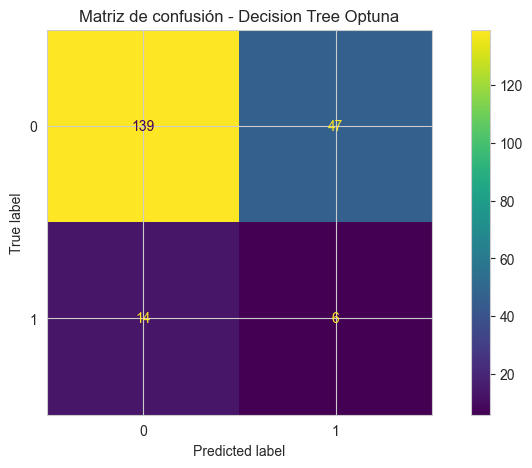

In [19]:
mejores_params = study_tree.best_params

modelo_tree_optuna = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=mejores_params["max_depth"],
        min_samples_split=mejores_params["min_samples_split"],
        min_samples_leaf=mejores_params["min_samples_leaf"],
        criterion=mejores_params["criterion"]
    ))
])

modelo_tree_optuna.fit(X_train, y_train)

resultado_tree_optuna = evaluar_modelo(
    "Decision Tree Optuna",
    modelo_tree_optuna,
    X_test,
    y_test
)


## Análisis de Optuna

Optuna logró encontrar parámetros distintos a los obtenidos por GridSearchCV, generando un modelo con mejor recall que el árbol optimizado manualmente.

Sin embargo, el rendimiento final todavía quedó por debajo de Logistic Regression.

Aun así, incorporar Optuna aporta bastante valor técnico al proyecto porque demuestra el uso de técnicas modernas de optimización automática de hiperparámetros.

Además, permite comparar distintos enfoques de búsqueda y analizar cómo cambia el comportamiento del modelo según la estrategia utilizada.


# 12. Comparación final de modelos

Se comparan los principales modelos obtenidos durante la etapa de optimización.


In [20]:
resultados = [
    resultado_tree_base,
    resultado_tree_grid,
    resultado_logistic_grid,
    resultado_tree_optuna
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,Logistic Regression GridSearchCV,0.650485,0.561022,0.128571,0.45,0.200000
0,Decision Tree Base,0.762136,0.555914,0.146341,0.30,0.196721
3,Decision Tree Optuna,0.703883,0.523656,0.113208,0.30,0.164384
1,Decision Tree GridSearchCV,0.548544,0.459946,0.080460,0.35,0.130841


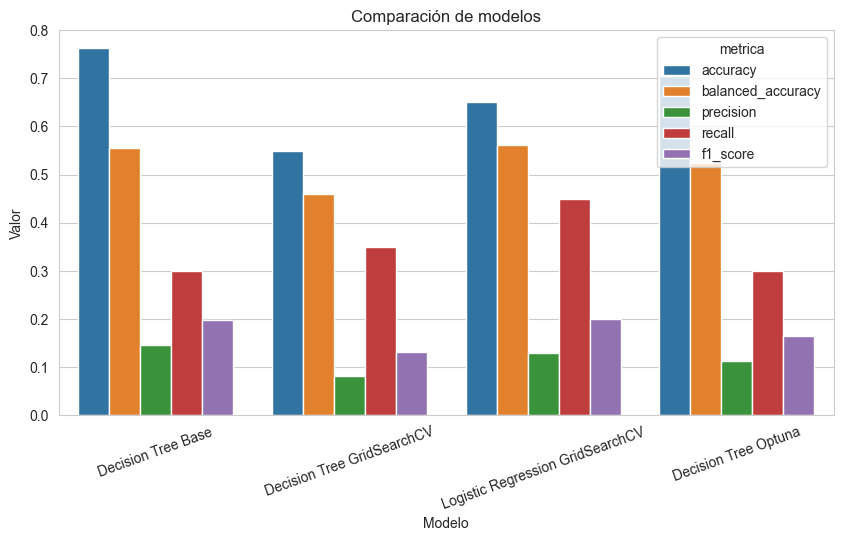

In [21]:
tabla_melt = tabla_resultados.melt(
    id_vars="modelo",
    value_vars=[
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score"
    ],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=tabla_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación de modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor")

plt.xticks(rotation=20)

plt.show()


## Análisis comparativo

Los resultados muestran que el modelo con mayor accuracy no necesariamente es el mejor modelo para este problema.

Por ejemplo, algunos modelos lograron accuracies relativamente altas, pero fallaron al detectar correctamente la clase minoritaria.

El mejor equilibrio general fue obtenido por:

### Logistic Regression + GridSearchCV

Esto se debe principalmente a:

- mejor recall,
- mejor F1-score,
- comportamiento más estable,
- mejor capacidad de generalización.

Aunque el F1-score final sigue siendo moderado, el modelo logra detectar una parte importante de las entregas tardías sin depender exclusivamente de la clase mayoritaria.


# 13. Selección del modelo final

El mejor modelo se selecciona utilizando principalmente:

- F1-score
- Recall
- Balanced Accuracy

La métrica accuracy no se considera suficiente debido al desbalance de clases.


In [22]:
mejor_modelo = tabla_resultados.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_modelo



modelo               Logistic Regression GridSearchCV
accuracy                                     0.650485
balanced_accuracy                            0.561022
precision                                    0.128571
recall                                           0.45
f1_score                                          0.2
Name: 2, dtype: object

# 14. Conclusiones finales

La etapa de optimización permitió analizar cómo distintos hiperparámetros afectan el rendimiento de los modelos de clasificación.

Las principales conclusiones obtenidas fueron:

- La redefinición de la variable objetivo permitió construir un problema de clasificación mucho más utilizable que la versión original.
- El dataset sigue presentando desbalance de clases, por lo que accuracy no es una métrica suficiente para evaluar el rendimiento real.
- `Decision Tree Base` logró resultados competitivos incluso antes de optimizar.
- `GridSearchCV` no mejoró el árbol de decisión, demostrando que optimizar hiperparámetros no garantiza automáticamente un mejor rendimiento en datos reales.
- `Logistic Regression GridSearchCV` obtuvo el mejor equilibrio general del proyecto, alcanzando el mejor F1-score y el mejor recall.
- `Optuna` permitió aplicar una estrategia moderna de optimización automática, aportando mayor profundidad experimental al proyecto.

En términos generales, los resultados muestran que el problema de predicción de entregas tardías es complejo y que las variables actuales poseen una capacidad predictiva moderada.

Sin embargo, el proyecto permitió desarrollar un flujo completo de Machine Learning, incluyendo:

- análisis exploratorio,
- selección de variables,
- construcción de targets,
- entrenamiento de modelos,
- evaluación,
- optimización,
- interpretación de métricas.

La siguiente etapa del proyecto consistirá en desarrollar un problema de regresión utilizando la variable:

`dias_entrega`

con el objetivo de estimar cuántos días podría tardar un envío.
